# Deep Hedging


## Libraries, General Settings and Helpers

In [24]:
import time
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [25]:
def to_tensor(x, dtype=torch.float32, device=device):
    """
    Converts input to a float32 torch tensor on the chosen device.
    """
    if torch.is_tensor(x):
        return x.to(device=device, dtype=dtype)
    return torch.tensor(x, dtype=dtype, device=device)

def to_numpy(x):
    """Convert a Torch tensor to NumPy; leave NumPy arrays unchanged."""
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return x

## Global Variables

In [26]:
# --- Market & Option Parameters ---
S0 = 100.0          # Initial stock price
K = 100.0           # Strike price
r = 0.05            # Risk-free rate
T = 30 / 365        # Time to maturity (e.g., 30 days)
epsilon = 0.005     # Proportional transaction cost (0.5%)

# --- Black-Scholes Parameters ---
sigma = 0.20        # Constant volatility

# --- Heston Model Parameters ---
v0 = 0.04           # Initial variance (e.g., 0.20^2)
kappa = 2.0         # Mean reversion speed
theta = 0.04        # Long-term mean variance
sigma_v = 0.30      # Volatility of variance (vol-of-vol)
rho = -0.70         # Correlation between asset and variance Brownian motions

# --- Simulation Parameters ---
steps = 30          # Number of time steps (e.g., daily hedging)
n_paths_sim = 10000 # Number of paths for baseline/evaluation

# --- Deep Hedging & Training Parameters ---
n_epochs = 1000
batch_size = 256
cvar_alpha = 0.95   # Confidence level for CVaR (95%)
learning_rate = 0.005

# Architecture params (Input: Log-Spot, [Vol for Heston], Prev Delta)
d_bs = 3            # Dimension for Black-Scholes
d_heston = 4        # Dimension for Heston
hidden_dim = [16,16]     # Number of hidden units

# Market Simulation

## Black and Scholes Path Generator

**The Math Behind the Path**

In a discrete-time setting, we update the price at each step $\Delta t$ using the following stochastic differential equation (SDE) solution:
$$S_{t+\Delta t} = S_t \exp\left( (r - \frac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$
where $Z \sim N(0, 1)$.

In [27]:
def generate_bs_paths(S0, r, sigma, T, steps, n_paths):
    """
    Generates Black-Scholes asset price paths.
    Returns a torch.Tensor of shape (steps + 1, n_paths).
    """
    dt = T / steps

    # Generate all random shocks at once: (steps, n_paths)
    Z = torch.randn(steps, n_paths, device=device)

    # Calculate log returns
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * (dt ** 0.5) * Z
    log_returns = drift + diffusion

    # Add a row of zeros at the start for S0
    zeros = torch.zeros(1, n_paths, device=device)
    cumulative_log_returns = torch.cumsum(torch.cat([zeros, log_returns], dim=0), dim=0)

    paths = S0 * torch.exp(cumulative_log_returns)

    return paths

## Heston Path Generator

### TODO - closer-to-paper Heston simulation

Current implementation uses a practical **full-truncation Euler** scheme with Monte Carlo finite-difference delta.

Later, to get closer to the paper, replace this with:
- **exact sampling of the CIR variance process**
- **simplified Broadie–Kaya scheme** for the Heston price process

The paper’s experiments use exact CIR transition sampling where available, rather than a simple Euler approximation.

The Heston model assumes that the variance of the underlying asset follows its own mean-reverting stochastic process. The dynamics are described by the following system of SDEs:
$$dS_t = r S_t dt + \sqrt{v_t} S_t dW_t^S$$
$$dv_t = \kappa(\theta - v_t)dt + \sigma_v \sqrt{v_t} dW_t^v$$

where the two Wiener processes are correlated such that $dW_t^S dW_t^v = \rho dt$. To simulate this in discrete time, we use an Euler-Maruyama discretization scheme with full truncation to ensure the variance remains positive.

In [28]:
def generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths):
    """
    Generates Heston asset price and variance paths.
    Returns two torch.Tensors of shape (steps + 1, n_paths) for S and v.
    """
    dt = T / steps

    S = torch.zeros(steps + 1, n_paths, device=device)
    v = torch.zeros(steps + 1, n_paths, device=device)

    S[0], v[0] = S0, v0

    for t in range(steps):
        # Correlated Brownian Motions
        Z1 = torch.randn(n_paths, device=device)
        Z2 = torch.randn(n_paths, device=device)
        W_S = Z1
        W_v = rho * Z1 + ((1 - rho**2)**0.5) * Z2

        # Update Variance (using full truncation to ensure v > 0)
        v_prev = torch.clamp(v[t], min=0.0)
        v[t+1] = torch.clamp(v_prev + kappa * (theta - v_prev) * dt + sigma_v * torch.sqrt(v_prev * dt) * W_v, 0)

        # Update Price
        S[t+1] = S[t] * torch.exp((r - 0.5 * v_prev) * dt + torch.sqrt(v_prev * dt) * W_S)

    return S, v

# Hedging

## B-S Delta

For a European Call option, the Black-Scholes delta is given by:
$$\Delta = \Phi(d_1)$$
where:
$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}}$$
and $\Phi$ is the cumulative distribution function (CDF) of the standard normal distribution. Note that $\tau$ is the time to maturity ($T - t$), which decreases at every step.

In [29]:
def calculate_bs_delta(S, K, r, sigma, tau):
    """
    Calculates the analytical Black-Scholes Delta for a Call option.

    tau: Time remaining to maturity (T - t)
    """
    # Maybe I delete this if i see we always use tensors
    S = to_tensor(S)
    tau = to_tensor(tau)

    eps=1e-6
    tau_clamped = torch.clamp(tau, min=eps)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * tau_clamped) / (sigma * torch.sqrt(tau_clamped))
    delta = torch.special.ndtr(d1)

    # At expiration, Delta is 1 if in-the-money, 0 otherwise. To avoid division by 0
    delta = torch.where(tau <= eps, (S > K).float(), delta)

    return delta

## Heston Numerical Delta

### TODO - closer-to-paper Heston benchmark

Current implementation:
- full-truncation Euler for the variance process
- log-Euler update for the stock
- Monte Carlo pricing + central finite-difference delta
- common random numbers + antithetic variates for variance reduction

Closer to the paper:
- exact sampling of the CIR variance transition
- simplified Broadie–Kaya scheme for the Heston stock process

This would make the Heston benchmark more faithful to the original paper, but is a second-step upgrade.

Because the Heston model lacks a straightforward analytical delta, we approximate it using finite differences. We calculate the option price via Monte Carlo simulation with antithetic method at a bumped-up spot price ($S + \epsilon$) and a bumped-down spot price ($S - \epsilon$), then estimate the gradient:
$$\Delta \approx \frac{C(S + \epsilon, v, t) - C(S - \epsilon, v, t)}{2\epsilon}$$

In [30]:
def simulate_heston_from_state(S0, v0, r, kappa, theta, sigma_v, rho, tau,
                               n_paths=1000, sub_steps=20, Z1=None, Z2=None):
    """
    Simulates terminal Heston stock prices from a batch of current states (S0, v0) up to remaining maturity tau.

    Parameters
    ----------
    S0 : tensor-like, shape (B,)
        Current spot values.
    v0 : tensor-like, shape (B,)
        Current variances.
    tau : tensor-like, shape (B,)
        Remaining maturities.
    n_paths : int
        Number of MC paths per state.
    sub_steps : int
        Number of time steps between now and maturity.
    Z1, Z2 : tensors, optional
        Random shocks of shape (sub_steps, B, n_paths).

    Returns
    -------
    S_T : tensor, shape (B, n_paths)
        Simulated terminal stock values for each batch state and MC path.
    """
    S0 = to_tensor(S0).reshape(-1)
    v0 = to_tensor(v0).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S0.shape[0]

    if Z1 is None or Z2 is None:
        Z1 = torch.randn(sub_steps, B, n_paths, device=device)
        Z2 = torch.randn(sub_steps, B, n_paths, device=device)

    # Each state has its own dt because tau may differ across states
    dt = tau / sub_steps                  # shape: (B,)
    sqrt_dt = torch.sqrt(dt)              # shape: (B,)

    # Expand each state across MC paths
    S_t = S0[:, None].expand(B, n_paths).clone()   # shape: (B, n_paths)
    v_t = v0[:, None].expand(B, n_paths).clone()   # shape: (B, n_paths)

    rho_t = torch.as_tensor(rho, device=device, dtype=S_t.dtype)
    sqrt_1_minus_rho2 = torch.sqrt(torch.clamp(1.0 - rho_t**2, min=0.0))

    for j in range(sub_steps):
        z1 = Z1[j]    # shape: (B, n_paths)
        z2 = Z2[j]    # shape: (B, n_paths)

        # Correlated shock for variance process
        z_v = rho_t * z1 + sqrt_1_minus_rho2 * z2

        dt_j = dt[:, None]           # shape: (B, 1)
        sqrt_dt_j = sqrt_dt[:, None] # shape: (B, 1)

        v_pos = torch.clamp(v_t, min=0.0)

        # Full truncation Euler for variance
        v_next = (v_t + kappa * (theta - v_pos) * dt_j + sigma_v * torch.sqrt(v_pos) * sqrt_dt_j * z_v)
        v_next = torch.clamp(v_next, min=0.0)

        # Stock update
        S_t = S_t * torch.exp((r - 0.5 * v_pos) * dt_j + torch.sqrt(v_pos) * sqrt_dt_j * z1)

        v_t = v_next

    return S_t

#=====================================================================================

def heston_price_mc(S, v, K, r, kappa, theta, sigma_v, rho, tau,
                    n_mc=1000, sub_steps=20, Z1=None, Z2=None,
                    return_stats=False):
    """
    Batched Heston call pricing by Monte Carlo from current states.

    Parameters
    ----------
    S : tensor-like, shape (B,)
        Current spot values.
    v : tensor-like, shape (B,)
        Current variances.
    tau : tensor-like, shape (B,)
        Remaining maturities.
    K, r, kappa, theta, sigma_v, rho : scalars
        Option/model parameters.
    n_mc : int
        Number of MC paths per state.
    sub_steps : int
        Number of simulation substeps.
    Z1, Z2 : tensors, optional
        Random shocks of shape (sub_steps, B, n_mc).
    return_stats : bool
        If True, also return std of discounted payoffs and MC std error.

    Returns
    -------
    price : tensor, shape (B,)
    std_payoff : tensor, shape (B,)      [if return_stats=True]
    std_error : tensor, shape (B,)       [if return_stats=True]
    """
    S = to_tensor(S).reshape(-1)
    v = to_tensor(v).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S.shape[0]

    price = torch.zeros_like(S)

    if return_stats:
        std_payoff_out = torch.zeros_like(S)
        std_error_out = torch.zeros_like(S)

    # Mask for non-expired states
    alive = tau > 1e-6

    # Expired states: option value = payoff
    if (~alive).any():
        price[~alive] = torch.clamp(S[~alive] - K, min=0.0)

        if return_stats:
            std_payoff_out[~alive] = 0.0
            std_error_out[~alive] = 0.0

    # Live states: run MC for the non expired options/states
    if alive.any():
        S_live = S[alive]         # shape: (B_live,)
        v_live = v[alive]
        tau_live = tau[alive]
        B_live = S_live.shape[0]

        S_T = simulate_heston_from_state(S0=S_live, v0=v_live, r=r, kappa=kappa, 
                                         theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                                         n_paths=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2)  # shape: (B_live, n_mc)

        payoff = torch.clamp(S_T - K, min=0.0)                     # (B_live, n_mc)
        discounted_payoff = torch.exp(-r * tau_live)[:, None] * payoff
        price_live = discounted_payoff.mean(dim=1)                 # (B_live,)

        price[alive] = price_live

        if return_stats:
            std_payoff_live = discounted_payoff.std(dim=1, unbiased=True)
            std_error_live = std_payoff_live / torch.sqrt(torch.tensor(n_mc, device=device, dtype=discounted_payoff.dtype))

            std_payoff_out[alive] = std_payoff_live
            std_error_out[alive] = std_error_live

    if return_stats:
        return price, std_payoff_out, std_error_out

    return price

#=========================================================================================

def calculate_heston_delta(S, v, K, r, kappa, theta, sigma_v, rho, tau,
                           n_mc=2000, sub_steps=20, bump_ratio=0.01, chunk_size=None):
    """
    Batched Heston delta via central finite differences.
    Uses common random numbers, antithetic variates, and optional chunking.
    """
    S = to_tensor(S).reshape(-1)
    v = to_tensor(v).reshape(-1)
    tau = to_tensor(tau).reshape(-1)

    B = S.shape[0]

    if chunk_size is not None and chunk_size < B:
        parts = []
        for start in range(0, B, chunk_size):
            end = min(start + chunk_size, B)
            delta_chunk = calculate_heston_delta(S=S[start:end], v=v[start:end], K=K, r=r,
                                                 kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho, tau=tau[start:end],
                                                 n_mc=n_mc, sub_steps=sub_steps, bump_ratio=bump_ratio,
                                                 chunk_size=None) # None break recursion
            parts.append(delta_chunk)
        return torch.cat(parts, dim=0)

    delta = torch.zeros_like(S)

    alive = tau > 1e-6

    if (~alive).any():
        delta[~alive] = (S[~alive] > K).float()

    if not alive.any():
        return delta

    S_live = S[alive]
    v_live = v[alive]
    tau_live = tau[alive]

    epsilon = torch.clamp(bump_ratio * S_live, min=1e-4)

    B_live = S_live.shape[0]
    half_mc = n_mc // 2

    Z1_half = torch.randn(sub_steps, B_live, half_mc, device=device)
    Z2_half = torch.randn(sub_steps, B_live, half_mc, device=device)

    Z1 = torch.cat([Z1_half, -Z1_half], dim=2)
    Z2 = torch.cat([Z2_half, -Z2_half], dim=2)

    price_up = heston_price_mc(S=S_live + epsilon, v=v_live, K=K, r=r, kappa=kappa,
                               theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                               n_mc=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2,
                               return_stats=False)

    price_down = heston_price_mc(S=S_live - epsilon, v=v_live, K=K, r=r, kappa=kappa,
                                 theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_live,
                                 n_mc=n_mc, sub_steps=sub_steps, Z1=Z1, Z2=Z2,
                                 return_stats=False)

    delta_live = (price_up - price_down) / (2.0 * epsilon)
    delta[alive] = delta_live

    return delta

## Baseline Simulation Runner

To evaluate our Deep Hedging model, we need a baseline to compare it against. These functions calculate the hedging PnL across all our simulated paths using the traditional analytical (Black-Scholes) or numerical (Heston) deltas. We also factor in the proportional transaction costs ($\epsilon$) to reflect real-world trading friction.

In [31]:
def run_bs_baseline(paths, K, r, sigma, T, epsilon, premium=0.0):
    """
    Computes the baseline hedging PnL using analytical Black-Scholes Delta.

    --------
    premium : initial price of the option, positive if seller and negative if buyer
    esplion : proportional transaction cost
    paths   : torch.Tensor of shape (steps + 1, n_paths)
    """
    # Convert to numpy for the analytical function
    paths = to_tensor(paths)

    n_steps, n_paths = paths.shape[0] - 1, paths.shape[1]
    dt = T / n_steps

    deltas = torch.zeros(n_steps, n_paths, device=device)

    for t_idx in range(n_steps):
        tau = T - (t_idx * dt)
        # Vectorized calculation across all paths at time t
        deltas[t_idx] = calculate_bs_delta(paths[t_idx], K, r, sigma, tau)

    # 1. Hedging Gains
    price_changes = paths[1:] - paths[:-1]
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2. Transaction Costs
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])
    diff_deltas = torch.abs(deltas[1:] - deltas[:-1])
    running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)
    total_costs = initial_cost + running_costs

    # 3. Payoff and Final PnL
    payoff = torch.clamp(paths[-1] - K, min=0.0)
    pnl = premium + hedging_gains - total_costs - payoff

    return deltas, pnl

#=========================================================================================
# Maybe i need to change premium which in theory is the price
def run_heston_baseline(paths, vol_paths, K, r, kappa, theta, sigma_v, rho, T,
                        epsilon, premium=0.0, chunk_size=None,
                        n_mc=2000, sub_steps=20, bump_ratio=0.01):
    """
    Compute seller-side baseline hedging PnL under Heston using
    batched finite-difference delta hedging with proportional costs.
    """
    paths = to_tensor(paths)
    vol_paths = to_tensor(vol_paths)

    n_steps = paths.shape[0] - 1
    n_paths = paths.shape[1]
    dt = T / n_steps

    deltas = torch.zeros(n_steps, n_paths, device=device)

    # Batched delta computation: one call per hedge date
    for t_idx in range(n_steps):
        tau_t = torch.full((n_paths,), T - t_idx * dt, device=device, dtype=paths.dtype)

        deltas[t_idx] = calculate_heston_delta(S=paths[t_idx], v=vol_paths[t_idx], K=K, r=r,
                                               kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho, tau=tau_t,
                                               n_mc=n_mc, sub_steps=sub_steps, bump_ratio=bump_ratio, chunk_size=chunk_size)

    # 1) Hedging gains
    price_changes = paths[1:] - paths[:-1]                  # (n_steps, n_paths)
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2) Transaction costs
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])

    if n_steps > 1:
        diff_deltas = torch.abs(deltas[1:] - deltas[:-1])   # (n_steps-1, n_paths)
        running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)
    else:
        running_costs = torch.zeros(n_paths, device=device, dtype=paths.dtype)

    total_costs = initial_cost + running_costs

    # 3) Payoff and final seller-side PnL
    payoff = torch.clamp(paths[-1] - K, min=0.0)
    pnl = premium + hedging_gains - total_costs - payoff

    return deltas, pnl

# Architecture

## Network Definition

### Base neural network block: `DeepHedgeNet`

This class defines the **core multilayer perceptron used as the building block of the hedging policies**.

It takes as input a feature vector describing the current hedging state and returns a single scalar output, interpreted as the hedge position proposed by the network.

**Architecture.**
- A fully connected feedforward neural network.
- Hidden layer sizes are specified by `hidden_dims`.
- Each hidden layer applies:
  1. a linear transformation,
  2. optional batch normalization,
  3. a ReLU activation.
- The final layer is linear and outputs a single scalar.

**Initialization.**
- All linear layers are initialized with **Xavier uniform initialization**.
- Biases are initialized to zero.

**Purpose.**
- `DeepHedgeNet` is not tied to a specific hedging architecture by itself.
- It serves as the reusable neural block inside both:
  - the **shared-parameter policy**, where the same network is reused at every time step;
  - the **per-time-step policy**, where one separate network is assigned to each hedging date.

**Input / Output.**
- **Input:** a tensor of shape `(batch_size, input_dim)` containing the current state features.
- **Output:** a tensor of shape `(batch_size,)` containing the predicted hedge ratio.

In [32]:
class DeepHedgeNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(16, 16), use_batch_norm=False):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)

### Shared-parameter policy

In this architecture, we use a **single feedforward neural network shared across all rebalancing dates**.  
At each time step $t_k$, the same network is applied to the current state features and the previous hedge position in order to produce the new hedge ratio:
$$
\delta_k^\theta = F^\theta(x_k, \delta_{k-1}).
$$

This provides a compact parametrization with relatively few trainable parameters, since the same weights are reused throughout the hedging horizon.

**Inputs.**
- **Black–Scholes:** normalized log-spot and previous hedge position.
- **Heston:** normalized log-spot, current variance (or volatility proxy), and previous hedge position.
- Time-to-maturity can also be included among the features.

**Architecture.**
- A single multilayer perceptron (`DeepHedgeNet`) is reused at every step.
- Hidden layers use ReLU activations.
- Batch normalization is optional and controlled through the `use_batch_norm` argument.

**Output.**
- A single scalar corresponding to the hedge position \(\delta_k\) at the current time step.

In [33]:
class SharedPolicy(nn.Module):
    def __init__(self, input_dim, hidden_dims=(16, 16), use_batch_norm=False):
        super().__init__()
        self.net = DeepHedgeNet(input_dim=input_dim, hidden_dims=hidden_dims, use_batch_norm=use_batch_norm)

    def forward_step(self, t, x):
        return self.net(x)

### Per-time-step policy

This policy assigns a **different neural network to each rebalancing date**.  
Instead of reusing the same parameters over the full hedging horizon, we define one decision rule per time step:
$$
\delta_k^\theta = F_k^\theta(x_k, \delta_{k-1}).
$$

Each $F_k^\theta$ is implemented by its own instance of `DeepHedgeNet`, and all of them are stored in a `ModuleList`.

**Architecture.**
- One `DeepHedgeNet` per hedging date.
- All networks share the same internal structure:
  - same input dimension,
  - same hidden layer sizes,
  - same activation functions,
  - same optional batch normalization setting.
- Parameters are **not shared across time**.

**Motivation.**
- This allows each network to specialize to the distribution and hedging behavior of its own time step.
- In particular, early and late hedging dates may require different decision rules, especially when transaction costs are present.

**Implementation.**
- `self.nets[t]` is the neural network associated with time step $t$.
- The method `forward_step(t, x)` applies the network corresponding to the current hedging date.

**Input / Output.**
- **Input:** a tensor of shape `(batch_size, input_dim)` containing the state features at time step $t$.
- **Output:** a tensor of shape `(batch_size,)` containing the hedge ratio predicted for that specific time step.

In [34]:
class PerStepPolicy(nn.Module):
    def __init__(self, steps, input_dim, hidden_dims=(16, 16), use_batch_norm=False):
        super().__init__()
        self.nets = nn.ModuleList([DeepHedgeNet(input_dim=input_dim, hidden_dims=hidden_dims, use_batch_norm=use_batch_norm)
                                   for _ in range(steps)])

    def forward_step(self, t, x):
        return self.nets[t](x)

## P&L with Transaction Costs

To evaluate a hedging strategy, we calculate the terminal Profit and Loss (PnL). For a short call option position being hedged, the PnL is defined as:
$$\text{PnL} = \text{Hedging Gains} - \text{Transaction Costs} - \text{Option Payoff}$$

We define the transaction cost at each time step $t$ as proportional to the trade size and current spot price:
$$Cost_t = \epsilon \cdot S_t \cdot |\delta_t - \delta_{t-1}|$$

where $\epsilon$ is the cost rate (e.g., $0.005$ for 0.5%). We must also account for the initial cost of entering the hedge: $\epsilon \cdot S_0 \cdot |\delta_0|$.

In [35]:
def get_pnl(paths, deltas, K, epsilon, premium=0.0, include_payoff=True):
    """
    Calculates the terminal PnL for a batch of simulated paths.

    paths: torch.Tensor of shape (steps + 1, n_paths)
    deltas: torch.Tensor of shape (steps, n_paths)
    K: Strike price
    epsilon: Proportional transaction cost
    """
    # 1. Hedging Gains (sum of delta * price change)
    price_changes = paths[1:] - paths[:-1]
    hedging_gains = torch.sum(deltas * price_changes, dim=0)

    # 2. Transaction Costs
    # Initial trade to set up the hedge at t=0
    initial_cost = epsilon * paths[0] * torch.abs(deltas[0])

    # Subsequent rebalancing trades
    diff_deltas = torch.abs(deltas[1:] - deltas[:-1])
    running_costs = torch.sum(epsilon * paths[1:-1] * diff_deltas, dim=0)

    total_costs = initial_cost + running_costs

    # 3. Terminal Payoff (Short Call)
    if include_payoff:
        payoff = torch.relu(paths[-1] - K)
    else:
        payoff = torch.zeros_like(paths[-1])

    # 4. Final Terminal PnL
    return premium + hedging_gains - total_costs - payoff

## CVaR Loss Function

To make CVaR differentiable for backpropagation, we use the Rockafellar-Uryasev formula:
$$\text{CVaR}_\alpha(L) = \min_{v} \left\{ v + \frac{1}{1-\alpha} \mathbb{E}[\max(0, L - v)] \right\}$$

where:
* $L$ is our loss (defined as negative PnL: $-PnL$).
* $v$ is a trainable parameter that converges to the Value at Risk ($\text{VaR}_\alpha$).
* $\alpha$ is our confidence level (e.g., 0.95 or 95%).

In [36]:
def cvar_loss(pnl, alpha, v_param):
    """
    Calculates the Conditional Value at Risk (Expected Shortfall).

    pnl: Tensor of terminal PnL
    alpha: Confidence level (e.g., 0.95)
    v_param: Learnable VaR threshold parameter (torch.nn.Parameter)
    """
    # Invert PnL to represent Loss (since PyTorch optimizers minimize the objective)
    losses = -pnl

    # Calculate the tail loss: max(0, Loss - VaR)
    tail_loss = torch.clamp(losses - v_param, min=0)

    # Return the Rockafellar-Uryasev objective
    return v_param + (1 / (1 - alpha)) * torch.mean(tail_loss)

## Entropic Risk Measure

For a position $X$ and a risk-aversion parameter $\lambda > 0$, the measure is defined as:
$$\rho(X) = \frac{1}{\lambda} \log \mathbb{E}[\exp(-\lambda X)]$$

where:
* $X$ is our terminal Profit and Loss (PnL).
* $\lambda$ is the risk-aversion parameter (higher values mean the network will penalize variance more heavily).

In [37]:
def entropic_loss(pnl, lambda_param=1.0):
    """
    Calculates the Entropic Risk Measure.
    Numerically stable implementation to prevent float32 overflow.
    """
    # x = -lambda * PnL
    x = -lambda_param * pnl

    # Mathematically: log(mean(exp(x))) == logsumexp(x) - log(N)
    N = x.shape[0]

    # torch.logsumexp safely handles extremely large exponents
    log_mean_exp = torch.logsumexp(x, dim=0) - torch.log(torch.tensor(N, dtype=x.dtype, device=x.device))

    return (1.0 / lambda_param) * log_mean_exp

# Training & Evaluation

In [38]:
def build_policy(policy_type, steps, input_dim, hidden_dims=(16, 16), use_batch_norm=False):
    if policy_type == "shared":
        return SharedPolicy(
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            use_batch_norm=use_batch_norm
        )
    elif policy_type == "per_step":
        return PerStepPolicy(
            steps=steps,
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            use_batch_norm=use_batch_norm
        )
    else:
        raise ValueError(f"Unknown policy_type: {policy_type}")

## Training Loop

This is our main Deep Hedging training pipeline. It generates fresh market paths for every batch to prevent overfitting (on-policy reinforcement learning). For each time step, the model observes the market state (Log-Spot price, previous Delta, and optionally Variance for the Heston model) and outputs a new hedge ratio.

The optimizer updates both the neural network weights $\theta$ and the Value-at-Risk threshold $v$ simultaneously to minimize the CVaR of our hedging PnL.

In [39]:
def train_model(env_type, S0, K, r, T, steps, epsilon, premium=0.0,
                hidden_dims = [16,16], batch_size=256, n_epochs=500, lr=0.005,
                loss_type='cvar', alpha=0.95, lambda_param=1.0, include_payoff=True,
                policy_type="shared", use_batch_norm=False, **env_params):
    """
    Trains the Deep Hedging model.
    loss_type: 'cvar' or 'entropic'
    """
    # 1. Setup Architecture
    if policy_type == "shared":
        input_dim = 4 if env_type == 'heston' else 3 # +1 due to tau to insert time
    else:
        input_dim = 3 if env_type == 'heston' else 2
    policy = build_policy(policy_type=policy_type, steps=steps, input_dim=input_dim, hidden_dims=hidden_dims, use_batch_norm=use_batch_norm).to(device)

    # 2. Setup Optimizer based on Loss Type
    if loss_type == 'cvar':
        v_var = nn.Parameter(torch.tensor(0.0, requires_grad=True, device=device))
        optimizer = torch.optim.Adam(list(policy.parameters()) + [v_var], lr=lr)
    elif loss_type == 'entropic':
        v_var = None # Not needed for Entropic Risk
        optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    else:
        raise ValueError("loss_type must be 'cvar' or 'entropic'")

    loss_history = []
    start_time = time.time()
    pbar = tqdm(range(n_epochs), desc=f"Training {env_type.upper()} ({loss_type.upper()})")

    for epoch in pbar:
        policy.train()
        optimizer.zero_grad()

        # 3. Generate fresh paths
        if env_type == 'heston':
            paths, vols = generate_heston_paths(S0=S0, v0=env_params['v0'], r=r,
                                                kappa=env_params['kappa'], theta=env_params['theta'],
                                                sigma_v=env_params['sigma_v'], rho=env_params['rho'],
                                                T=T, steps=steps, n_paths=batch_size)
        else:
            paths = generate_bs_paths(S0=S0, r=r, sigma=env_params['sigma'],
                                      T=T, steps=steps, n_paths=batch_size)

        # 4. Forward pass through time
        all_deltas = []
        prev_delta = torch.zeros(batch_size, device=device, dtype=paths.dtype)

        for t in range(steps):
            log_spot = torch.log(paths[t] / S0).unsqueeze(1)
            if policy_type == "shared":
                dt = T / steps
                tau_t = torch.full((batch_size, 1), T - t * dt, device=device, dtype=paths.dtype)

            prev_delta_col = prev_delta.unsqueeze(1)  # (batch, 1)
            if env_type == 'heston':
                vol_current = vols[t].unsqueeze(1)
                if policy_type == "shared":
                    x = torch.cat([log_spot, vol_current, tau_t, prev_delta_col], dim=1)
                else:
                    x = torch.cat([log_spot, vol_current, prev_delta_col], dim=1)
            else:
                if policy_type == "shared":
                    x = torch.cat([log_spot, tau_t, prev_delta_col], dim=1)
                else:
                    x = torch.cat([log_spot, prev_delta_col], dim=1)

            curr_delta = policy.forward_step(t, x)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

        deltas = torch.stack(all_deltas, dim=0)

        # 5. Compute PnL
        pnl = get_pnl(paths, deltas, K, epsilon, premium = premium, include_payoff=include_payoff)

        # 6. Calculate Target Loss
        if loss_type == 'cvar':
            loss = cvar_loss(pnl, alpha, v_var)
        else:
            loss = entropic_loss(pnl, lambda_param)

        # 7. Backpropagation
        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        loss_history.append(loss_value)

        if loss_type == 'cvar':
            pbar.set_postfix(loss=f"{loss_value:.4f}", v=f"{v_var.item():.4f}")
        else:
            pbar.set_postfix(loss=f"{loss_value:.4f}")

    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed:.2f} seconds.")

    return {"model": policy,
            "v_var": v_var.item() if v_var is not None else None,
            "loss_history": loss_history,
            "final_loss": loss_history[-1]}

## Evaluation Metrics

Once the model is trained, we need to test it on a large, unseen dataset to evaluate its true performance. The evaluation function computes the Deep Hedging deltas across these test paths and calculates key risk metrics on the resulting P&L distribution.

* **Mean & Std**: The average profit/loss and its volatility.
* **VaR (95%)**: The maximum loss at the 95% confidence level.
* **CVaR (95%)**: The expected loss *given* that the loss has exceeded the VaR threshold.
* **Turnover**: The average absolute sum of position changes (shows how aggressively the network trades).

In [40]:
def evaluate_model(policy, env_type, test_paths, K, epsilon, S0, T, premium = 0.0, test_vols=None, include_payoff=True):
    """
    Evaluates the trained Deep Hedge network on out-of-sample test paths.
    """
    policy.eval()

    test_paths = to_tensor(test_paths)
    if test_vols is not None:
        test_vols = to_tensor(test_vols)

    steps = test_paths.shape[0] - 1
    dt = T / steps
    is_shared = isinstance(policy, SharedPolicy) 
    n_paths = test_paths.shape[1]

    all_deltas = []
    prev_delta = torch.zeros(n_paths, device=device, dtype=test_paths.dtype)

    # Disable gradient computation for faster inference
    with torch.no_grad():
        for t in range(steps):
            log_spot = torch.log(test_paths[t] / S0).unsqueeze(1)
            if is_shared:
                tau_t = torch.full((n_paths, 1), T - t * dt, device=device, dtype=test_paths.dtype)
            prev_delta_col = prev_delta.unsqueeze(1)

            if env_type == 'heston':
                if test_vols is None:
                    raise ValueError("test_vols must be provided for env_type='heston'")
                vol_current = test_vols[t].unsqueeze(1)

                if is_shared:
                    x = torch.cat([log_spot, vol_current, tau_t, prev_delta_col], dim=1)
                else:
                    x = torch.cat([log_spot, vol_current, prev_delta_col], dim=1)
            else:
                if is_shared:
                    x = torch.cat([log_spot, tau_t, prev_delta_col], dim=1)
                else:
                    x = torch.cat([log_spot, prev_delta_col], dim=1)

            curr_delta = policy.forward_step(t, x)
            all_deltas.append(curr_delta)
            prev_delta = curr_delta

    deltas = torch.stack(all_deltas, dim=0)
    pnl = get_pnl(test_paths, deltas, K, epsilon, premium=premium, include_payoff=include_payoff)

    # Calculate Risk Metrics
    # Note: VaR and CVaR are typically reported as positive numbers for losses
    losses = -pnl
    var_95 = torch.quantile(losses, 0.95)
    var_99 = torch.quantile(losses, 0.99)

    # Only average the losses that are strictly greater than the VaR threshold
    tail_losses = losses[losses >= var_95]
    cvar_95 = tail_losses.mean() if tail_losses.numel() > 0 else var_95
    cvar_99 = losses[losses >= var_99].mean()

    # Turnover: sum of absolute changes in delta
    initial_trade = torch.abs(deltas[0])
    rehedge_trades = torch.abs(deltas[1:] - deltas[:-1])

    turnover = torch.mean(initial_trade + torch.sum(rehedge_trades, dim=0))

    total_cost_per_path = epsilon * (test_paths[0] * initial_trade + torch.sum(test_paths[1:-1] * rehedge_trades, dim=0))
    avg_total_cost = total_cost_per_path.mean()

    metrics = {
        "Mean PnL": pnl.mean().item(),
        "Std PnL": pnl.std(unbiased=False).item(),
        "Loss VaR (95%)": var_95.item(),
        "Loss CVaR (95%)": cvar_95.item(),
        "Loss VaR (99%)": var_99.item(),
        "Loss CVaR (99%)": cvar_99.item(),
        "Turnover": turnover.item(),
        "Avg Total Transaction Cost": avg_total_cost.item(),
    }

    return metrics, to_numpy(pnl), to_numpy(deltas)

# Experiment

### Helpers

In [41]:
def plot_pnl_diagnostics(pnl_baseline, pnl_model, baseline_name, model_name, title_suffix="", bins=80):
    pnl_baseline = to_numpy(pnl_baseline)
    pnl_model = to_numpy(pnl_model)

    pnl_baseline = np.asarray(pnl_baseline)
    pnl_model = np.asarray(pnl_model)

    # ---------- Histogram ----------
    plt.figure(figsize=(9, 5))
    plt.hist(pnl_baseline, bins=bins, density=True, alpha=0.5, label=baseline_name)
    plt.hist(pnl_model, bins=bins, density=True, alpha=0.5, label=model_name)
    plt.axvline(np.mean(pnl_baseline), linestyle="--", label=f"{baseline_name} mean = {np.mean(pnl_baseline):.3f}")
    plt.axvline(np.mean(pnl_model), linestyle="--", label=f"{model_name} mean = {np.mean(pnl_model):.3f}")
    plt.title(f"P&L Histogram {title_suffix}")
    plt.xlabel("Terminal P&L")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---------- Empirical CDF ----------
    def empirical_cdf(x):
        x_sorted = np.sort(x)
        y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
        return x_sorted, y

    x_b, y_b = empirical_cdf(pnl_baseline)
    x_m, y_m = empirical_cdf(pnl_model)

    plt.figure(figsize=(9, 5))
    plt.plot(x_b, y_b, label=baseline_name)
    plt.plot(x_m, y_m, label=model_name)
    plt.title(f"Empirical CDF of P&L {title_suffix}")
    plt.xlabel("Terminal P&L")
    plt.ylabel("Empirical CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---------- Left-tail zoom ----------
    plt.figure(figsize=(9, 5))
    plt.plot(x_b, y_b, label=baseline_name)
    plt.plot(x_m, y_m, label=model_name)
    plt.xlim(min(pnl_baseline.min(), pnl_model.min()), np.quantile(np.concatenate([pnl_baseline, pnl_model]), 0.25))
    plt.ylim(0.0, 0.2)
    plt.title(f"Empirical CDF of P&L (Left Tail Zoom) {title_suffix}")
    plt.xlabel("Terminal P&L")
    plt.ylabel("Empirical CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#=====================================================================================================

def print_results_comparison(title, baseline_name, baseline_metrics, model_name, model_metrics):
    """
    Print comparison table between a baseline hedge and deep hedging.
    """
    metric_order = ["Mean PnL",
                    "Std PnL",
                    "Loss VaR (95%)",
                    "Loss CVaR (95%)",
                    "Loss VaR (99%)",
                    "Loss CVaR (99%)",
                    "Turnover",
                    "Avg Total Transaction Cost"]

    print(f"\n=== {title} ===")
    print(f"{'Metric':<18} | {baseline_name:<15} | {model_name:<15}")
    print("-" * 58)

    for metric in metric_order:
        if metric in baseline_metrics and metric in model_metrics:
            print(f"{metric:<18} | {baseline_metrics[metric]:>15.4f} | {model_metrics[metric]:>15.4f}")

#================================================================================

def compute_metrics_from_pnl_and_deltas(pnl, deltas, paths=None, epsilon=None):
    pnl = to_numpy(pnl)
    deltas = to_numpy(deltas)

    pnl = np.asarray(pnl)
    deltas = np.asarray(deltas)

    losses = -pnl
    var_95 = np.percentile(losses, 95)
    cvar_95 = np.mean(losses[losses >= var_95])
    var_99 = np.percentile(losses, 99)
    cvar_99 = np.mean(losses[losses >= var_99])

    # include initial trade from 0 -> delta_0
    initial_trade = np.abs(deltas[0])
    rehedge_trades = np.abs(np.diff(deltas, axis=0))

    total_turnover_per_path = initial_trade + np.sum(rehedge_trades, axis=0)

    metrics = {
        "Mean PnL": float(np.mean(pnl)),
        "Std PnL": float(np.std(pnl)),
        "Loss VaR (95%)": float(var_95),
        "Loss CVaR (95%)": float(cvar_95),
        "Loss VaR (99%)": float(var_99),
        "Loss CVaR (99%)": float(cvar_99),
        "Turnover": float(np.mean(total_turnover_per_path)),
    }

    # optional transaction-cost metric
    if paths is not None and epsilon is not None:
        paths = to_numpy(paths)
        paths = np.asarray(paths)

        # costs at times 0,...,steps-1 for trades into delta_0, ..., delta_{steps-1}
        total_cost_per_path = epsilon * (
            paths[0] * initial_trade +
            np.sum(paths[1:-1] * rehedge_trades, axis=0)
        )

        metrics["Avg Total Transaction Cost"] = float(np.mean(total_cost_per_path))

    return metrics

## Black & Scholes

### Pricer

In [42]:
class BlackScholesPricer:
    def __init__(self, S0, r, sigma, q=0.0, device=None, dtype=torch.float32):
        self.device = device if device is not None else torch.device("cpu")
        self.dtype = dtype

        self.S0 = torch.as_tensor(S0, device=self.device, dtype=self.dtype)
        self.r = torch.as_tensor(r, device=self.device, dtype=self.dtype)
        self.sigma = torch.as_tensor(sigma, device=self.device, dtype=self.dtype)
        self.q = torch.as_tensor(q, device=self.device, dtype=self.dtype)

        self.eps = torch.tensor(1e-12, device=self.device, dtype=self.dtype)
        self.sqrt2 = torch.sqrt(torch.tensor(2.0, device=self.device, dtype=self.dtype))

    def std_norm_cdf(self, x):
        return 0.5 * (1.0 + torch.erf(x / self.sqrt2))

    def call_price(self, K, T, S=None):
        """
        Black-Scholes European call price.
        Returns a torch scalar.
        """
        S = self.S0 if S is None else torch.as_tensor(S, device=self.device, dtype=self.dtype)
        K = torch.as_tensor(K, device=self.device, dtype=self.dtype)
        T = torch.as_tensor(T, device=self.device, dtype=self.dtype)

        if T.item() <= 0:
            return torch.clamp(S - K, min=0.0)

        if self.sigma.item() <= 0:
            return torch.clamp(S - K * torch.exp(-self.r * T), min=0.0)

        sqrtT = torch.sqrt(T)
        d1 = (torch.log(S / K) + (self.r - self.q + 0.5 * self.sigma**2) * T) / (self.sigma * sqrtT + self.eps)
        d2 = d1 - self.sigma * sqrtT

        return S * torch.exp(-self.q * T) * self.std_norm_cdf(d1) - K * torch.exp(-self.r * T) * self.std_norm_cdf(d2)

    def put_price(self, K, T, S=None):
        """
        Black-Scholes European put price via put-call parity.
        """
        S = self.S0 if S is None else torch.as_tensor(S, device=self.device, dtype=self.dtype)
        K = torch.as_tensor(K, device=self.device, dtype=self.dtype)
        T = torch.as_tensor(T, device=self.device, dtype=self.dtype)

        call = self.call_price(K, T, S=S)
        return call - S * torch.exp(-self.q * T) + K * torch.exp(-self.r * T)

    def price(self, K, T, option_type="C", S=None):
        option_type = str(option_type).upper()
        if option_type == "C":
            return self.call_price(K, T, S=S)
        elif option_type == "P":
            return self.put_price(K, T, S=S)
        else:
            raise ValueError("option_type must be 'C' or 'P'")

### B-S without transaction costs (need to change)

As a baseline sanity check, we first train and evaluate the model in a Black-Scholes environment with zero transaction costs ($\epsilon = 0$). In this frictionless setup, the optimal strategy mathematically proven to minimize variance is the analytical Black-Scholes Delta. Our neural network should naturally converge to this exact strategy.

In [51]:
policy_type="per_step"
#policy_type="shared"
print(f'UNDER POLICY: {policy_type}')

print("--- Generating Test Set ---")
test_paths_bs = generate_bs_paths(S0, r, sigma, T, steps, n_paths_sim)

# 1. Run Analytical Baseline
print("Running Analytical Black-Scholes Baseline...")
bs_pricer = BlackScholesPricer(S0=S0, r=r, sigma=sigma, q=0.0, device=device, dtype=torch.float32)
premium_bs = bs_pricer.call_price(K, T)
print("BS premium:", premium_bs.item())
bs_deltas_0, bs_pnl_0 = run_bs_baseline(test_paths_bs, K, r, sigma, T, epsilon=0.0, premium=premium_bs)

# Calculate baseline metrics
bs_metrics_0 = compute_metrics_from_pnl_and_deltas(bs_pnl_0, bs_deltas_0, paths=test_paths_bs, epsilon=0.0)
print(f"Baseline Loss CVaR (95%): {bs_metrics_0['Loss CVaR (95%)']:.4f}")

# 2. Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (eps = 0.0) ---")
train_out_bs_0 = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                             epsilon=0.0, batch_size=batch_size, n_epochs=n_epochs,
                             sigma=sigma, premium=premium_bs, policy_type=policy_type,    
                             use_batch_norm=False)
model_bs_0 = train_out_bs_0["model"]

# 3. Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_bs_0, dh_pnl_0, dh_deltas_0 = evaluate_model(model_bs_0, 'bs', test_paths_bs, K, epsilon=0.0, S0=S0, T=T,
                                                     premium=premium_bs)

# 4. Compare Results
print_results_comparison(title="RESULTS COMPARISON (NO COSTS)",
                         baseline_name="Analytical BS",
                         baseline_metrics=bs_metrics_0,
                         model_name="Deep Hedging",
                         model_metrics=metrics_bs_0)

UNDER POLICY: per_step
--- Generating Test Set ---
Running Analytical Black-Scholes Baseline...
BS premium: 2.493377685546875
Baseline Loss CVaR (95%): 0.6624

--- Training Deep Hedging Model (eps = 0.0) ---


Training BS (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 20.26 seconds.

--- Evaluating Deep Hedging Model ---

=== RESULTS COMPARISON (NO COSTS) ===
Metric             | Analytical BS   | Deep Hedging   
----------------------------------------------------------
Mean PnL           |          0.2100 |          0.2100
Std PnL            |          0.3729 |          0.5655
Loss VaR (95%)     |          0.4051 |          0.6399
Loss CVaR (95%)    |          0.6624 |          0.8739
Loss VaR (99%)     |          0.7966 |          1.0097
Loss CVaR (99%)    |          1.0844 |          1.2180
Turnover           |          2.2416 |          2.2720
Avg Total Transaction Cost |          0.0000 |          0.0000


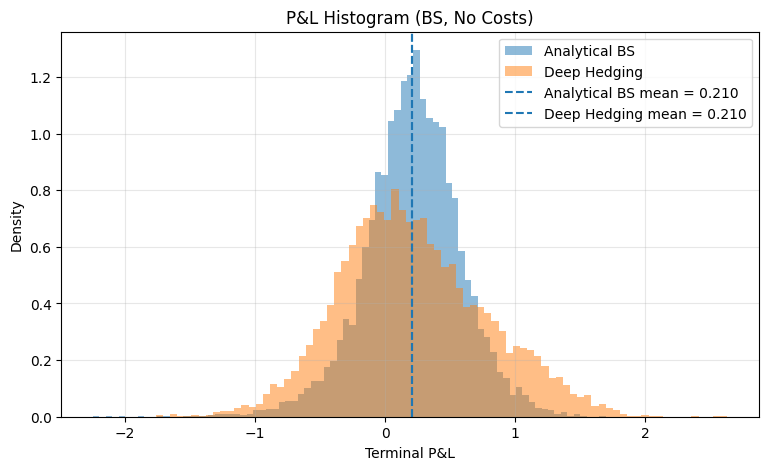

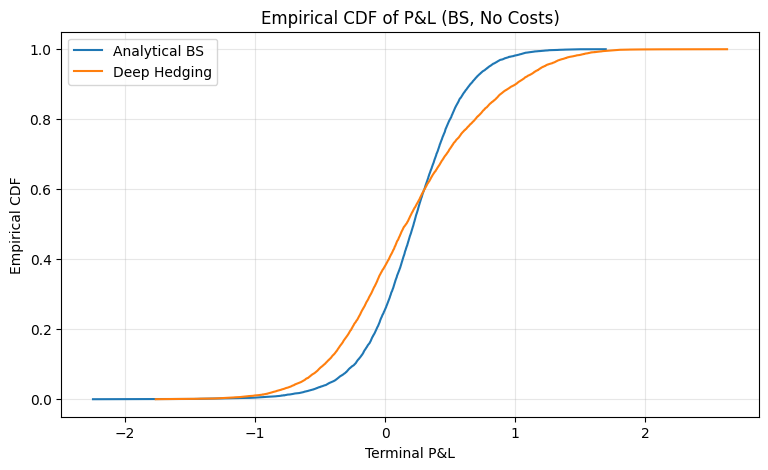

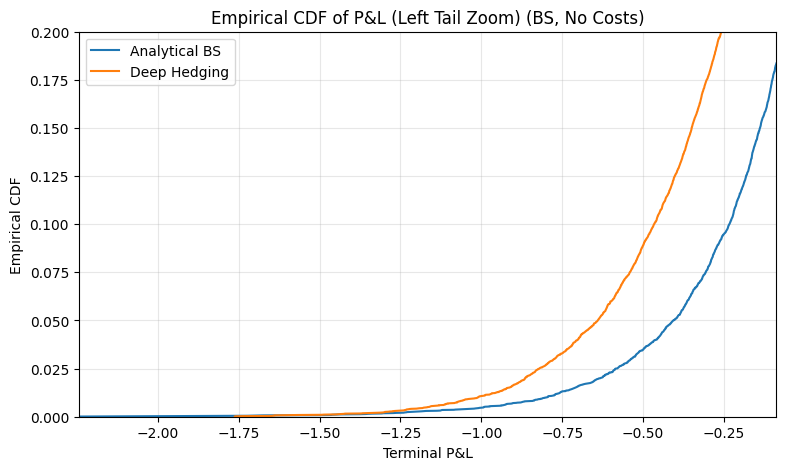

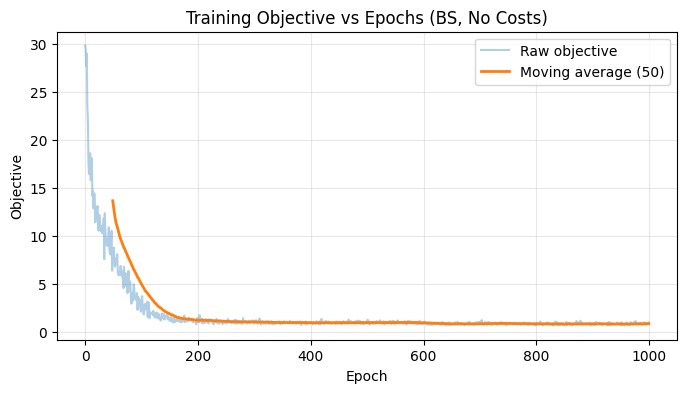

In [52]:
# 5. Plot Diagnostics
plot_pnl_diagnostics(pnl_baseline=bs_pnl_0,
                     pnl_model=dh_pnl_0,
                     baseline_name="Analytical BS",
                     model_name="Deep Hedging",
                     title_suffix="(BS, No Costs)")

# 6. Training Diagnostics
loss_hist = np.asarray(train_out_bs_0["loss_history"])
window = 50

if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(8, 4))
    plt.plot(loss_hist, alpha=0.35, label="Raw objective")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed, linewidth=2, label=f"Moving average ({window})")
else:
    plt.figure(figsize=(8, 4))
    plt.plot(loss_hist, label="Objective")

plt.title("Training Objective vs Epochs (BS, No Costs)")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### B-S with transaction costs (need to change)

Now we introduce market friction by setting our transaction cost rate to 0.5%. The traditional Black-Scholes delta ignores these costs and will over-trade, racking up huge fees. Our Deep Hedging model, trained with these costs included in its PnL function, should learn to trade less aggressively, resulting in a significantly lower Turnover and a better overall CVaR.

In [53]:
print(f'UNDER POLICY: {policy_type}')
print("--- Running Analytical Baseline (eps = 0.005) ---")
# We reuse the test_paths_bs from Experiment 1 for a fair comparison
bs_deltas_cost, bs_pnl_cost = run_bs_baseline(test_paths_bs, K, r, sigma, T, epsilon=epsilon, premium=premium_bs)

# Calculate baseline metrics
bs_metrics_cost = compute_metrics_from_pnl_and_deltas(
    bs_pnl_cost,
    bs_deltas_cost,
    paths=test_paths_bs,
    epsilon=epsilon
)
print(f"Baseline Loss CVaR (95%): {bs_metrics_cost['Loss CVaR (95%)']:.4f}")


# Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (eps = 0.005) ---")
train_out_bs_cost = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                                sigma=sigma, premium=premium_bs)
model_bs_cost = train_out_bs_cost["model"]

# Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_bs_cost, dh_pnl_cost, dh_deltas_cost = evaluate_model(model_bs_cost, 'bs', test_paths_bs, K, epsilon=epsilon, S0=S0, T=T, premium=premium_bs)

# Compare Results
print_results_comparison(title="RESULTS COMPARISON (WITH 0.5% COSTS)",
                         baseline_name="Analytical BS",
                         baseline_metrics=bs_metrics_cost,
                         model_name="Deep Hedging",
                         model_metrics=metrics_bs_cost)

UNDER POLICY: per_step
--- Running Analytical Baseline (eps = 0.005) ---
Baseline Loss CVaR (95%): 2.2475

--- Training Deep Hedging Model (eps = 0.005) ---


Training BS (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 21.92 seconds.

--- Evaluating Deep Hedging Model ---

=== RESULTS COMPARISON (WITH 0.5% COSTS) ===
Metric             | Analytical BS   | Deep Hedging   
----------------------------------------------------------
Mean PnL           |         -0.9106 |         -0.5154
Std PnL            |          0.5231 |          0.6282
Loss VaR (95%)     |          1.8782 |          1.4222
Loss CVaR (95%)    |          2.2475 |          1.6232
Loss VaR (99%)     |          2.4795 |          1.7403
Loss CVaR (99%)    |          2.8325 |          1.9179
Turnover           |          2.2416 |          1.4236
Avg Total Transaction Cost |          1.1206 |          0.7119


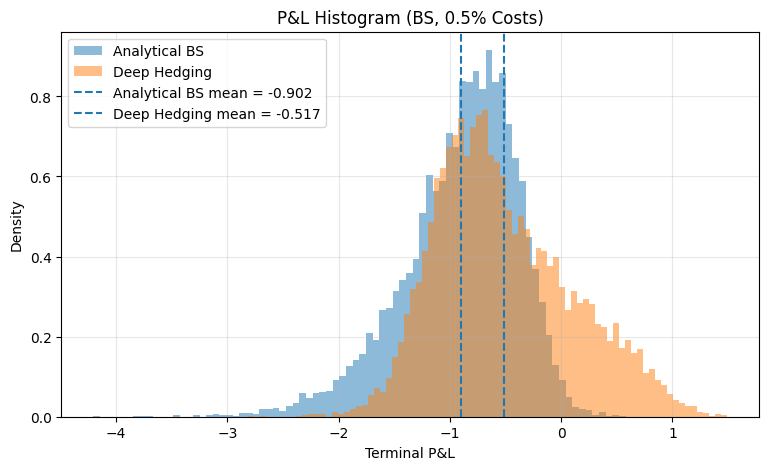

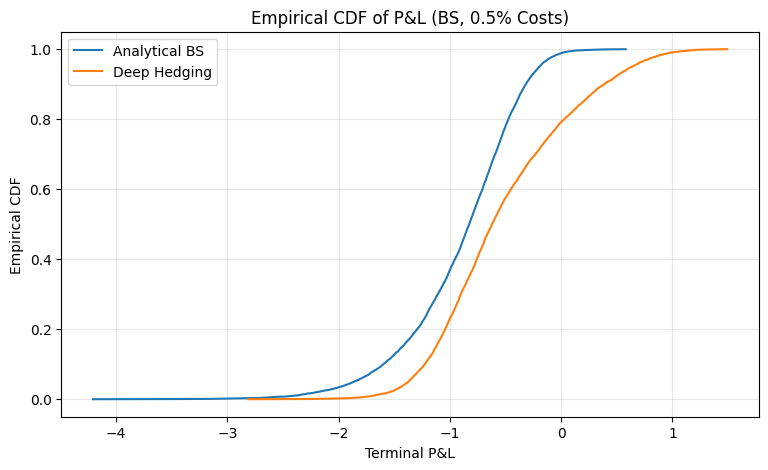

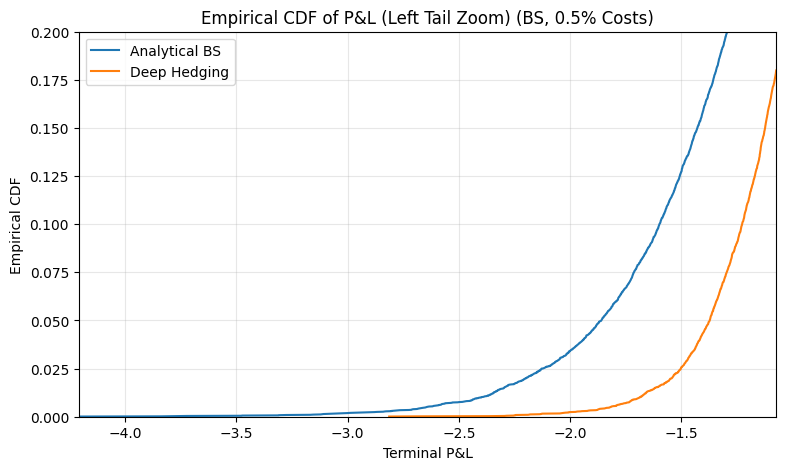

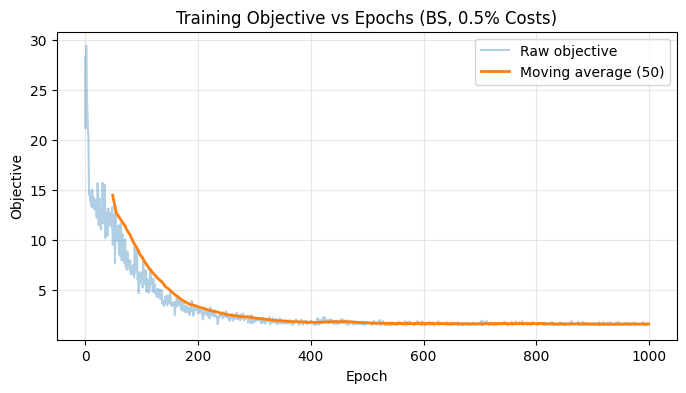

In [46]:
# Plot Diagnostics
plot_pnl_diagnostics(pnl_baseline=bs_pnl_cost,
                     pnl_model=dh_pnl_cost,
                     baseline_name="Analytical BS",
                     model_name="Deep Hedging",
                     title_suffix="(BS, 0.5% Costs)")

# Training Diagnostics
loss_hist = np.asarray(train_out_bs_cost["loss_history"])
window = 50

plt.figure(figsize=(8, 4))
if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    plt.plot(loss_hist, alpha=0.35, label="Raw objective")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed, linewidth=2, label=f"Moving average ({window})")
else:
    plt.plot(loss_hist, label="Objective")

plt.title("Training Objective vs Epochs (BS, 0.5% Costs)")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Heston

In [47]:
class HestonPricer:
    """
    Heston option pricer via Fourier inversion.
    Uses the Gil-Pelaez formula with Gauss-Legendre quadrature on [0, U].
    Call price: C = S * e^{-qT} * P1 - K * e^{-rT} * P2
    where P1, P2 are risk-neutral probabilities obtained from the characteristic function.
    """
    def __init__(self, S0, r, kappa, theta, xi, rho, v0,
                 q=0.0, U=80.0, n_pts=64, device=None, dtype=torch.float64):

        self.device = device if device is not None else torch.device("cpu")
        self.dtype = dtype

        self.S0 = torch.tensor(float(S0), device=self.device, dtype=self.dtype)
        self.r = torch.tensor(float(r), device=self.device, dtype=self.dtype)
        self.q = torch.tensor(float(q), device=self.device, dtype=self.dtype)

        self.kappa = torch.tensor(float(kappa), device=self.device, dtype=self.dtype)
        self.theta = torch.tensor(float(theta), device=self.device, dtype=self.dtype)
        self.xi = torch.tensor(float(xi), device=self.device, dtype=self.dtype)
        self.rho = torch.tensor(float(rho), device=self.device, dtype=self.dtype)
        self.v0 = torch.tensor(float(v0), device=self.device, dtype=self.dtype)

        self.logS0 = torch.log(self.S0)

        x_np, w_np = np.polynomial.legendre.leggauss(int(n_pts))
        x = torch.tensor(x_np, device=self.device, dtype=self.dtype)
        w = torch.tensor(w_np, device=self.device, dtype=self.dtype)

        U_t = torch.tensor(float(U), device=self.device, dtype=self.dtype)
        self.u = 0.5 * U_t * (x + 1.0)
        self.w = 0.5 * U_t * w

    def _cf(self, u, T):
        """
        Heston characteristic function E[e^{iu log(S_T)}].
        """
        T = torch.tensor(float(T), device=self.device, dtype=self.dtype).to(torch.complex128)
        u = torch.as_tensor(u, device=self.device, dtype=torch.complex128)

        kappa = self.kappa.to(torch.complex128)
        theta = self.theta.to(torch.complex128)
        xi = self.xi.to(torch.complex128)
        rho = self.rho.to(torch.complex128)
        v0 = self.v0.to(torch.complex128)
        r = self.r.to(torch.complex128)
        q = self.q.to(torch.complex128)
        logS0 = self.logS0.to(torch.complex128)

        i = torch.tensor(1j, device=self.device, dtype=torch.complex128)

        b = kappa - rho * xi * i * u
        d = torch.sqrt((rho * xi * i * u - kappa) ** 2 + xi**2 * (u**2 + i * u))
        g = (b - d) / (b + d)
        e = torch.exp(-d * T)

        C = ((r - q) * i * u * T + (kappa * theta / xi**2) * ((b - d) * T - 2.0 * torch.log((1.0 - g * e) / (1.0 - g))))
        D = ((b - d) / xi**2) * ((1.0 - e) / (1.0 - g * e))

        return torch.exp(C + D * v0 + i * u * logS0)

    def _p1_p2(self, K, T):
        """
        Risk-neutral probabilities P1 and P2 for scalar strike K.
        """
        K = torch.tensor(float(K), device=self.device, dtype=self.dtype)
        logK = torch.log(K)

        u = self.u
        phi_u = self._cf(u, T)
        phi_u_i = self._cf(u - 1j, T)
        phi_mi = self._cf(torch.tensor([-1j], device=self.device, dtype=torch.complex128), T)[0]

        u_c = u.to(torch.complex128)
        logK_c = logK.to(torch.complex128)
        w = self.w

        expo = torch.exp(-1j * logK_c * u_c)

        integrand1 = torch.real(expo * (phi_u_i / (1j * u_c * phi_mi)))
        integrand2 = torch.real(expo * (phi_u / (1j * u_c)))

        P1 = 0.5 + torch.sum(integrand1 * w) / torch.pi
        P2 = 0.5 + torch.sum(integrand2 * w) / torch.pi

        return P1, P2

    def call_price(self, K, T):
        """
        Scalar European call price under Heston.
        """
        K_t = torch.tensor(float(K), device=self.device, dtype=self.dtype)
        T_t = torch.tensor(float(T), device=self.device, dtype=self.dtype)

        P1, P2 = self._p1_p2(K_t, T_t)
        call = self.S0 * torch.exp(-self.q * T_t) * P1 - K_t * torch.exp(-self.r * T_t) * P2
        return float(call.item())

    def put_price(self, K, T):
        """
        Scalar European put price under Heston via put-call parity.
        """
        K_t = torch.tensor(float(K), device=self.device, dtype=self.dtype)
        T_t = torch.tensor(float(T), device=self.device, dtype=self.dtype)

        call = self.call_price(K, T)
        put = call - float((self.S0 * torch.exp(-self.q * T_t)).item()) + float((K_t * torch.exp(-self.r * T_t)).item())
        return float(put)

    def price(self, K, T, option_type="C"):
        """
        Scalar price dispatcher. Option_type: 'C' or 'P'
        """
        option_type = str(option_type).upper()
        if option_type == "C":
            return self.call_price(K, T)
        elif option_type == "P":
            return self.put_price(K, T)
        else:
            raise ValueError("option_type must be 'C' or 'P'")

### Heston with transaction costs

Our final experiment tests the deep hedging framework in a much more complex environment: the Heston model. Here, volatility is no longer constant but follows its own stochastic process. The baseline relies on a computationally heavy finite-difference Monte Carlo approach.

Our Deep Hedging network takes three inputs at each step ($I_k$): the log-spot price, the current variance, and the previous position. It learns to balance the risks of both the asset's price movements and the volatility surface changes, all while navigating transaction costs.

In [48]:
policy_type = "per_step"      # or "per_step"
use_batch_norm = False      # or True

In [54]:
print("--- Generating Heston Test Set ---")
test_paths_h, test_vols_h = generate_heston_paths(S0, v0, r, kappa, theta, sigma_v, rho, T, steps, n_paths_sim)

# 1. Run Baseline 
print("Running Numerical Heston Baseline...")
heston_pricer = HestonPricer(S0=S0, r=r, kappa=kappa, theta=theta, xi=sigma_v, rho=rho, v0=v0,
                             device=device, dtype=torch.float64)

premium_h = heston_pricer.call_price(K, T)
print(f"Heston premium: {premium_h:.4f}")

h_deltas_base, h_pnl_base = run_heston_baseline(test_paths_h, test_vols_h, K, r, kappa, theta, sigma_v, rho, T,
                                                epsilon=epsilon, premium=premium_h)

# Calculate baseline metrics
h_metrics_base = compute_metrics_from_pnl_and_deltas(
    h_pnl_base,
    h_deltas_base,
    paths=test_paths_h,
    epsilon=epsilon
)
print(f"Baseline Loss CVaR (95%): {h_metrics_base['Loss CVaR (95%)']:.4f}")


# 2. Train Deep Hedging Model
print("\n--- Training Deep Hedging Model (Heston) ---")
train_out_h_base = train_model(env_type='heston', S0=S0, K=K, r=r, T=T, steps=steps,
                               epsilon=epsilon, batch_size=batch_size, n_epochs=n_epochs,
                               lr=learning_rate, hidden_dims=hidden_dim,
                               v0=v0, kappa=kappa, theta=theta, sigma_v=sigma_v, rho=rho,
                               premium=premium_h, alpha=cvar_alpha,
                               policy_type=policy_type, use_batch_norm=use_batch_norm)

model_h_base = train_out_h_base["model"]

# 3. Evaluate Deep Hedging Model
print("\n--- Evaluating Deep Hedging Model ---")
metrics_h, dh_pnl_h, dh_deltas_h = evaluate_model(model_h_base, 'heston', test_paths_h, K,
                                                  epsilon=epsilon, S0=S0, T=T,
                                                  test_vols=test_vols_h, premium=premium_h)

# Optional sanity checks
print(f"Deep Hedge Delta Min: {dh_deltas_h.min():.4f}")
print(f"Deep Hedge Delta Max: {dh_deltas_h.max():.4f}")
print(f"Deep Hedge Mean |Delta|: {abs(dh_deltas_h).mean():.4f}")

# 4. Compare Results
print_results_comparison(title="RESULTS COMPARISON (HESTON WITH COSTS)",
                         baseline_name="Numerical Heston",
                         baseline_metrics=h_metrics_base,
                         model_name=f"Deep Hedging ({policy_type})",
                         model_metrics=metrics_h)

--- Generating Heston Test Set ---
Running Numerical Heston Baseline...
Heston premium: 2.4866
Baseline Loss CVaR (95%): 2.3398

--- Training Deep Hedging Model (Heston) ---


Training HESTON (CVAR):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 32.74 seconds.

--- Evaluating Deep Hedging Model ---
Deep Hedge Delta Min: -0.1643
Deep Hedge Delta Max: 1.3267
Deep Hedge Mean |Delta|: 0.5202

=== RESULTS COMPARISON (HESTON WITH COSTS) ===
Metric             | Numerical Heston | Deep Hedging (per_step)
----------------------------------------------------------
Mean PnL           |         -0.8951 |         -0.5020
Std PnL            |          0.6274 |          0.6856
Loss VaR (95%)     |          1.9967 |          1.5185
Loss CVaR (95%)    |          2.3398 |          1.8191
Loss VaR (99%)     |          2.5667 |          1.9840
Loss CVaR (99%)    |          2.9011 |          2.3468
Turnover           |          2.2541 |          1.4337
Avg Total Transaction Cost |          1.1264 |          0.7188


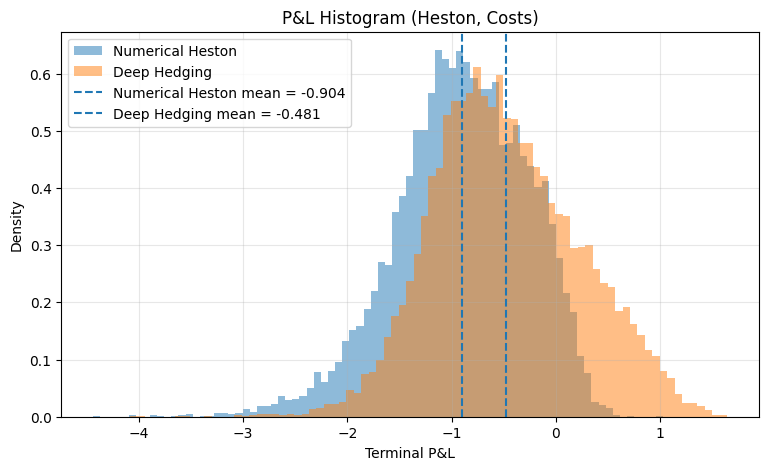

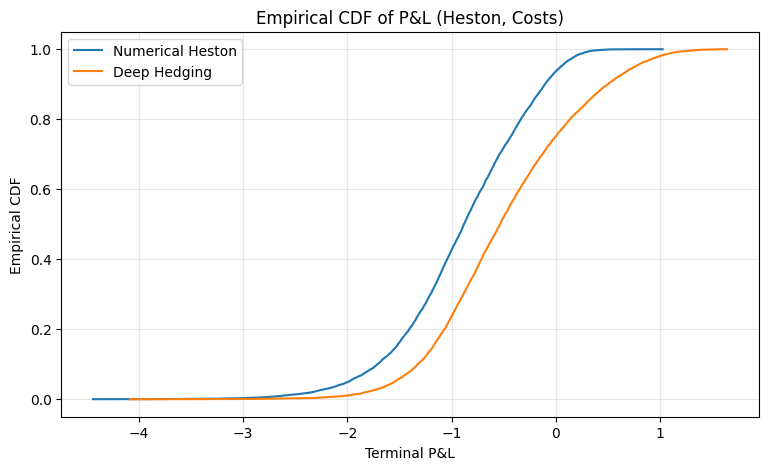

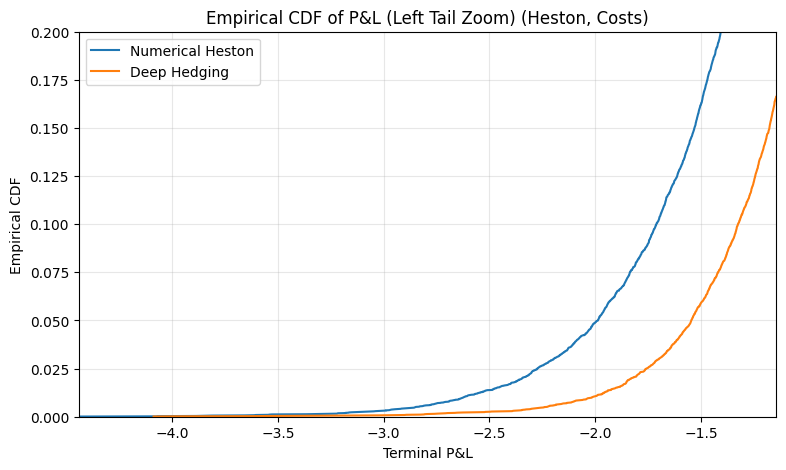

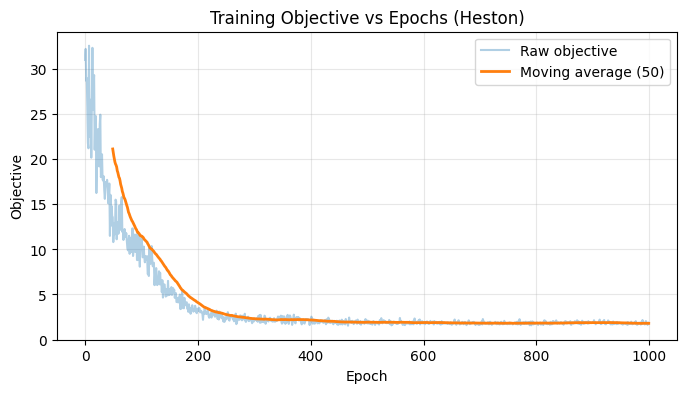

In [ ]:
# 5. Plot Diagnostics
plot_pnl_diagnostics(pnl_baseline=h_pnl_base,
                     pnl_model=dh_pnl_h,
                     baseline_name="Numerical Heston",
                     model_name="Deep Hedging",
                     title_suffix="(Heston, Costs)")

# 6. Training Diagnostics
loss_hist = np.asarray(train_out_h_base["loss_history"])
window = 50

plt.figure(figsize=(8, 4))
if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    plt.plot(loss_hist, alpha=0.35, label="Raw objective")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed, linewidth=2, label=f"Moving average ({window})")
else:
    plt.plot(loss_hist, label="Objective")

plt.title("Training Objective vs Epochs (Heston)")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## B-S with Entropic Risk Measure

In this experiment, we switch our loss function from CVaR to the Entropic Risk Measure ($\lambda = 1.0$) under proportional transaction costs ($\epsilon = 0.005$).

This exactly replicates the objective function used by the authors to calculate the exponential utility indifference price.

We expect the network to find a strategy that balances variance reduction with transaction cost savings.

In [55]:
print("--- Training Deep Hedging Model (Entropic Loss, eps = 0.005) ---")

# 1. Train the model using the new loss_type
train_out_bs_entropic = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps, epsilon=epsilon,
                                    premium=premium_bs, batch_size=batch_size, n_epochs=n_epochs, sigma=sigma,
                                    loss_type='entropic', lambda_param=1.0)      # Set risk aversion
model_bs_entropic =  train_out_bs_entropic["model"]                       

# 2. Evaluate the Entropic Model
print("\n--- Evaluating Entropic Deep Hedging Model ---")
# We reuse test_paths_bs generated back in Experiment 1
metrics_bs_entropic, entropic_pnl, entropic_deltas = evaluate_model(model_bs_entropic, 'bs', test_paths_bs, K, epsilon=epsilon, S0=S0, T=T,
                                                                    premium=premium_bs)

# 3. Compare Results against baseline and CVaR model
print("\n=== RESULTS COMPARISON (0.5% COSTS) ===")
print(f"{'Metric':<25} | {'Analytical BS':<15} | {'Deep Hedge (CVaR)':<18} | {'Deep Hedge (Entropic)':<22}")
print("-" * 95)
print(f"{'Mean PnL':<25} | {bs_metrics_cost['Mean PnL']:>15.4f} | {metrics_bs_cost['Mean PnL']:>18.4f} | {metrics_bs_entropic['Mean PnL']:>22.4f}")
print(f"{'Std PnL':<25} | {bs_metrics_cost['Std PnL']:>15.4f} | {metrics_bs_cost['Std PnL']:>18.4f} | {metrics_bs_entropic['Std PnL']:>22.4f}")
print(f"{'Loss VaR (95%)':<25} | {bs_metrics_cost['Loss VaR (95%)']:>15.4f} | {metrics_bs_cost['Loss VaR (95%)']:>18.4f} | {metrics_bs_entropic['Loss VaR (95%)']:>22.4f}")
print(f"{'Loss CVaR (95%)':<25} | {bs_metrics_cost['Loss CVaR (95%)']:>15.4f} | {metrics_bs_cost['Loss CVaR (95%)']:>18.4f} | {metrics_bs_entropic['Loss CVaR (95%)']:>22.4f}")
print(f"{'Loss VaR (99%)':<25} | {bs_metrics_cost['Loss VaR (99%)']:>15.4f} | {metrics_bs_cost['Loss VaR (99%)']:>18.4f} | {metrics_bs_entropic['Loss VaR (99%)']:>22.4f}")
print(f"{'Loss CVaR (99%)':<25} | {bs_metrics_cost['Loss CVaR (99%)']:>15.4f} | {metrics_bs_cost['Loss CVaR (99%)']:>18.4f} | {metrics_bs_entropic['Loss CVaR (99%)']:>22.4f}")
print(f"{'Turnover':<25} | {bs_metrics_cost['Turnover']:>15.4f} | {metrics_bs_cost['Turnover']:>18.4f} | {metrics_bs_entropic['Turnover']:>22.4f}")
print(f"{'Avg Total Transaction Cost':<25} | {bs_metrics_cost['Avg Total Transaction Cost']:>15.4f} | {metrics_bs_cost['Avg Total Transaction Cost']:>18.4f} | {metrics_bs_entropic['Avg Total Transaction Cost']:>22.4f}")

--- Training Deep Hedging Model (Entropic Loss, eps = 0.005) ---


Training BS (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 22.12 seconds.

--- Evaluating Entropic Deep Hedging Model ---

=== RESULTS COMPARISON (0.5% COSTS) ===
Metric                    | Analytical BS   | Deep Hedge (CVaR)  | Deep Hedge (Entropic) 
-----------------------------------------------------------------------------------------------
Mean PnL                  |         -0.9106 |            -0.5154 |                -0.3460
Std PnL                   |          0.5231 |             0.6282 |                 0.7831
Loss VaR (95%)            |          1.8782 |             1.4222 |                 1.6113
Loss CVaR (95%)           |          2.2475 |             1.6232 |                 1.9525
Loss VaR (99%)            |          2.4795 |             1.7403 |                 2.1433
Loss CVaR (99%)           |          2.8325 |             1.9179 |                 2.4774
Turnover                  |          2.2416 |             1.4236 |                 1.0728
Avg Total Transaction Cost |          1.1206 |            

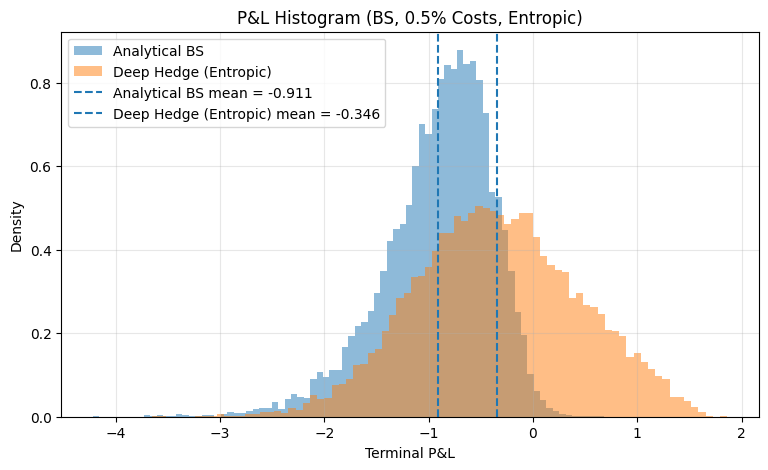

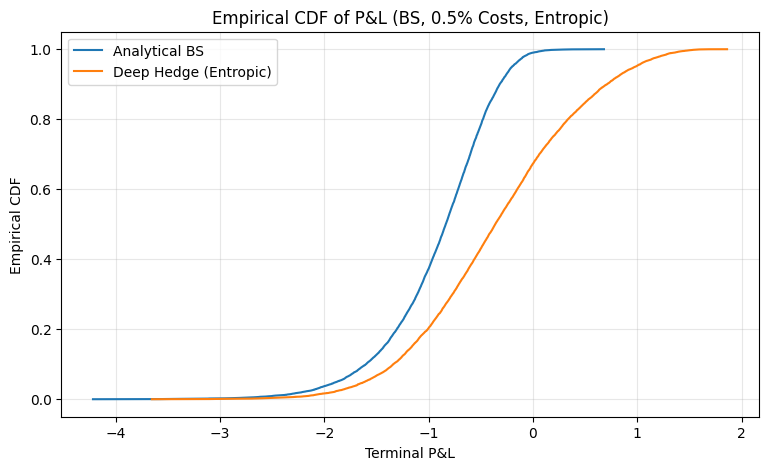

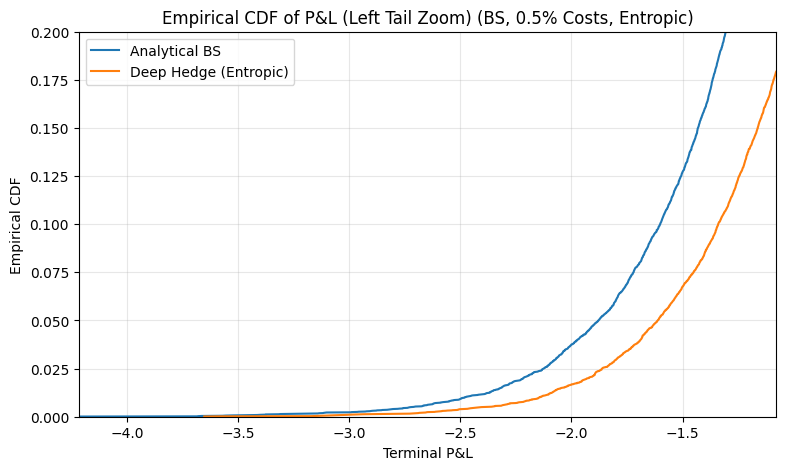

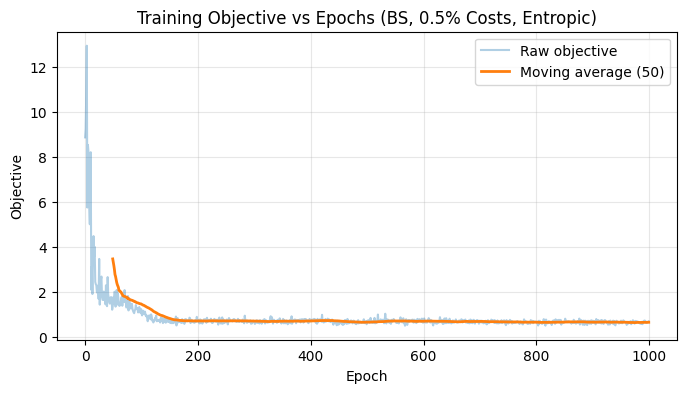

In [56]:
# Plot Diagnostics for Entropic Deep Hedging vs Analytical BS
plot_pnl_diagnostics(pnl_baseline=bs_pnl_cost,
                     pnl_model=entropic_pnl,
                     baseline_name="Analytical BS",
                     model_name="Deep Hedge (Entropic)",
                     title_suffix="(BS, 0.5% Costs, Entropic)")

# Training Diagnostics for Entropic Model
loss_hist = np.asarray(train_out_bs_entropic["loss_history"])
window = 50

plt.figure(figsize=(8, 4))
if len(loss_hist) >= window:
    smoothed = np.convolve(loss_hist, np.ones(window) / window, mode="valid")
    plt.plot(loss_hist, alpha=0.35, label="Raw objective")
    plt.plot(np.arange(window - 1, len(loss_hist)), smoothed, linewidth=2,
             label=f"Moving average ({window})")
else:
    plt.plot(loss_hist, label="Objective")

plt.title("Training Objective vs Epochs (BS, 0.5% Costs, Entropic)")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Asymptotic movements

Check if 0.67 is with brodie-kaya approximation scheme

In Section 5.3 of the paper, the authors prove that their deep hedging framework successfully learns the theoretical asymptotic convergence of transaction costs. Specifically, as proportional transaction costs ($\epsilon$) approach zero, the difference between the utility indifference price with costs ($p_\epsilon$) and the frictionless price ($p_0$) scales at a rate of $O(\epsilon^{2/3})$.

We replicate this by training the network over a decreasing sequence of $\epsilon$ values using the Entropic Risk Measure, and plotting the log-differences to extract the regression slope. We expect a slope of approximately 0.67.

--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---

Training for epsilon = 0.01562...


Training BS (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 19.60 seconds.


Training BS (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 19.60 seconds.
p_eps = 4.247871, p0 = 2.493378, p_eps - p0 = 1.754494e+00

Training for epsilon = 0.00781...


...

Training completed in 20.03 seconds.
p_eps = 2.734546, p0 = 2.493378, p_eps - p0 = 2.411680e-01

Training for epsilon = 0.00098...


Training BS (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 21.98 seconds.


Training BS (ENTROPIC):   0%|          | 0/1000 [00:00<?, ?it/s]

Training completed in 19.83 seconds.
p_eps = 2.574916, p0 = 2.493378, p_eps - p0 = 8.153820e-02


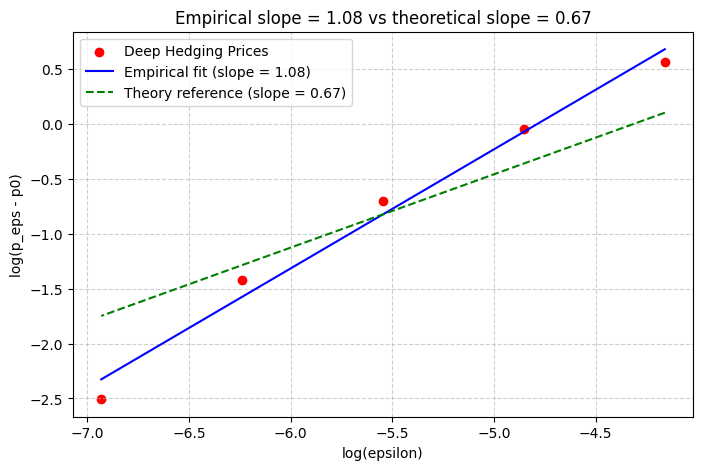

In [57]:
print("--- Running Transaction Cost Asymptotics O(eps^(2/3)) ---")
# n_epochs = 700

# 1. Calculate the frictionless baseline price (p0)
# The paper compares against the theoretical risk-neutral price q[cite: 764].
p0 = premium_bs.item()

# 2. Define the sequence of epsilons
# (Using 2^(-i-5) to match the paper's log-scale axis from roughly -7.0 to -4.5) [cite: 784, 785, 786, 787, 788, 789]
epsilons = [2**(-i-5) for i in range(1, 6)]

price_diffs = []
valid_eps = []

# 3. Training Loop over epsilons
for eps in epsilons:
    print(f"\nTraining for epsilon = {eps:.5f}...")

    # Train the model with Entropic loss for this specific epsilon
    #  WITH option liability
    train_out_with = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                 epsilon=eps, batch_size=batch_size, n_epochs=n_epochs,
                                 sigma=sigma, loss_type='entropic', lambda_param=1.0)
    model_with = train_out_with["model"] 

    # Evaluate to get out-of-sample PnL
    with torch.no_grad():
        _, pnl_with, _ = evaluate_model(model_with, 'bs', test_paths_bs, K, epsilon=eps, S0=S0, T=T)

    # Calculate the Indifference Price using the stable logsumexp trick
    risk_with = entropic_loss(to_tensor(pnl_with), lambda_param=1.0).item()

    # Train WITHOUT option liability
    train_out_without = train_model(env_type='bs', S0=S0, K=K, r=r, T=T, steps=steps,
                                    epsilon=eps, batch_size=batch_size, n_epochs=n_epochs,
                                    sigma=sigma, loss_type='entropic', lambda_param=1.0,
                                    premium=0.0, include_payoff=False)
    model_without = train_out_without["model"]

    with torch.no_grad():
        _, pnl_without, _ = evaluate_model(model_without, 'bs', test_paths_bs, K, epsilon=eps, S0=S0, T=T,
                                           premium=0.0, include_payoff=False)

    risk_without = entropic_loss(to_tensor(pnl_without), lambda_param=1.0).item()

    # Indifference price
    p_eps = risk_with - risk_without
    diff = p_eps - p0

    print(f"p_eps = {p_eps:.6f}, p0 = {p0:.6f}, p_eps - p0 = {diff:.6e}")

    if diff > 0:
        valid_eps.append(eps)
        price_diffs.append(diff)
    else:
        print("Skipping epsilon because p_eps - p0 <= 0")

# 4. Log-log regression
if len(valid_eps) < 2:
    print("Not enough valid epsilon points with p_eps - p0 > 0 to run log-log regression.")
else:
    log_eps = np.log(np.array(valid_eps))
    log_diffs = np.log(np.array(price_diffs))

    # empirical fit
    slope_emp, intercept_emp = np.polyfit(log_eps, log_diffs, 1)

    # Fixed theoretical slope = 2/3
    slope_theory = 2/3
    intercept_theory = np.mean(log_diffs - slope_theory * log_eps)

    # 5. Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(log_eps, log_diffs, color='red', label='Deep Hedging Prices')

    # Empirical best-fit line
    plt.plot(log_eps, slope_emp * log_eps + intercept_emp, color='blue', label=f'Empirical fit (slope = {slope_emp:.2f})')

    # Theoretical 2/3 reference line
    plt.plot(log_eps, slope_theory * log_eps + intercept_theory, color='green', linestyle='--', label='Theory reference (slope = 0.67)')

    plt.xlabel('log(epsilon)')
    plt.ylabel('log(p_eps - p0)')
    plt.title(f'Empirical slope = {slope_emp:.2f} vs theoretical slope = 0.67')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()